<a href="https://colab.research.google.com/github/catacg/BDS-book/blob/master/Required_Task_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data setup
Upload `xbd_teaching_subset.zip` to the current Colab runtime. Expected contents after extraction:

```text
xbd_teaching_subset/
  labels.csv
  pre_images/
  post_images/
```

This cell sets up the data by checking for the zipped dataset, extracting it if necessary, and then loading the `labels.csv` file into a pandas DataFrame. It also displays basic information about the loaded labels.

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
ZIP_PATH = Path('xbd_teaching_subset.zip')
DATA_DIR = Path('xbd_teaching_subset')
if not ZIP_PATH.exists():
    matches = list(Path.cwd().rglob('xbd_teaching_subset.zip'))
    if matches:
        ZIP_PATH = matches[0]
if not DATA_DIR.exists():
    assert ZIP_PATH.exists(), 'Upload xbd_teaching_subset.zip to the Colab runtime, then rerun this cell.'
    print('Extracting:', ZIP_PATH.resolve())
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
else:
    print('Using existing extracted folder:', DATA_DIR.resolve())
if not (DATA_DIR/'labels.csv').exists() and Path('labels.csv').exists():
    DATA_DIR = Path('.')
labels = pd.read_csv(DATA_DIR/'labels.csv')
print('DATA_DIR:', DATA_DIR.resolve())
print('Rows:', len(labels))
display(labels.head())
display(labels.damage_label.value_counts())
display(pd.crosstab(labels.split, labels.damage_label))

Extracting: /content/xbd_teaching_subset.zip
DATA_DIR: /content/xbd_teaching_subset
Rows: 400


,crop_id,tile_id,pre_image,post_image,damage_label,damage_id,bbox_x0,bbox_y0,bbox_x1,bbox_y1,split
0,hurricane-matthew_00000040_0023,hurricane-matthew_00000040,pre_images/hurricane-matthew_00000040_0023_pre...,post_images/hurricane-matthew_00000040_0023_po...,minor-damage,1,522,466,556,500,val
1,hurricane-michael_00000492_0017,hurricane-michael_00000492,pre_images/hurricane-michael_00000492_0017_pre...,post_images/hurricane-michael_00000492_0017_po...,minor-damage,1,968,18,1024,74,train
2,hurricane-matthew_00000110_0005,hurricane-matthew_00000110,pre_images/hurricane-matthew_00000110_0005_pre...,post_images/hurricane-matthew_00000110_0005_po...,destroyed,3,343,698,382,738,test
3,hurricane-michael_00000008_0008,hurricane-michael_00000008,pre_images/hurricane-michael_00000008_0008_pre...,post_images/hurricane-michael_00000008_0008_po...,minor-damage,1,148,303,309,464,train
4,santa-rosa-wildfire_00000237_0007,santa-rosa-wildfire_00000237,pre_images/santa-rosa-wildfire_00000237_0007_p...,post_images/santa-rosa-wildfire_00000237_0007_...,destroyed,3,900,270,967,338,train


,count
damage_label,
minor-damage,100
destroyed,100
no-damage,100
major-damage,100


damage_label,destroyed,major-damage,minor-damage,no-damage
split,,,,
test,16,8,15,14
train,62,83,73,65
val,22,9,12,21


This cell imports essential libraries for data manipulation, image processing, deep learning with PyTorch, and plotting. It also defines global constants like the device (CPU/GPU), sets a random seed for reproducibility, defines mappings for damage labels, and includes utility functions for loading images and displaying image grids.

In [2]:
import math, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything(42)
DAMAGE_TO_ID={'no-damage':0,'minor-damage':1,'major-damage':2,'destroyed':3}
ID_TO_DAMAGE={v:k for k,v in DAMAGE_TO_ID.items()}
def load_image(path, size=64):
    img=Image.open(path).convert('RGB').resize((size,size))
    arr=np.array(img).astype('float32')/255.0
    arr=arr*2.0-1.0
    return torch.from_numpy(arr).permute(2,0,1)
def show_grid(xs, titles=None, ncols=4, figsize=(10,6)):
    xs=xs.detach().cpu().clamp(-1,1); xs=(xs+1)/2
    n=len(xs); ncols=min(ncols,n); nrows=math.ceil(n/ncols)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrows,ncols,i+1); plt.imshow(xs[i].permute(1,2,0).numpy()); plt.axis('off')
        if titles is not None: plt.title(titles[i], fontsize=8)
    plt.tight_layout(); plt.show()

Device: cpu


## Dataset

This cell defines the `PostDamageDataset` class, a custom PyTorch Dataset for loading images and their corresponding damage labels. It then initializes the training, validation, and test datasets and dataloaders, and displays a sample of images from the training set with their labels.

Train: 283 Val: 64 Test: 53


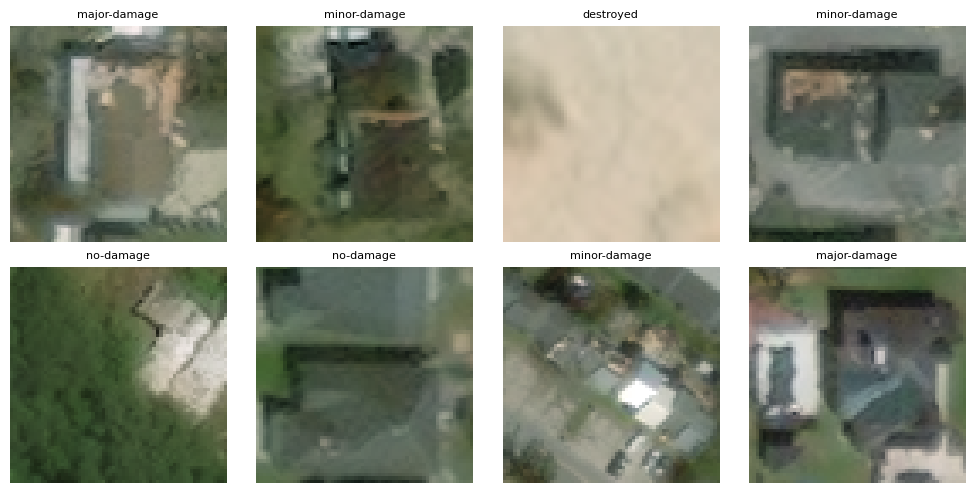

In [3]:
class PostDamageDataset(Dataset):
    def __init__(self,data_dir,labels,split='train',image_size=64):
        self.data_dir=Path(data_dir); self.df=labels[labels['split'].eq(split)].reset_index(drop=True); self.image_size=image_size
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        r=self.df.iloc[idx]; return load_image(self.data_dir/r.post_image,self.image_size), int(r.damage_id)
IMAGE_SIZE=64; BATCH_SIZE=64
train_ds=PostDamageDataset(DATA_DIR,labels,'train',IMAGE_SIZE); val_ds=PostDamageDataset(DATA_DIR,labels,'val',IMAGE_SIZE); test_ds=PostDamageDataset(DATA_DIR,labels,'test',IMAGE_SIZE)
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=0); val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=0); test_loader=DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)
print('Train:',len(train_ds),'Val:',len(val_ds),'Test:',len(test_ds))
x,y=next(iter(train_loader)); show_grid(x[:8],[ID_TO_DAMAGE[int(c)] for c in y[:8]],ncols=4,figsize=(10,5))

## Class balance and weights

This cell analyzes the class balance within the training data and calculates class weights. These weights are used in the loss function to mitigate the impact of class imbalance during model training.

In [4]:
display(pd.crosstab(labels['split'],labels['damage_label']))
class_counts=labels[labels['split'].eq('train')]['damage_id'].value_counts().sort_index(); class_weights=torch.ones(4)
for cls_id in range(4):
    if cls_id in class_counts.index: class_weights[cls_id]=len(train_ds)/(4*class_counts.loc[cls_id])
class_weights=class_weights.to(DEVICE); print('Class weights:',class_weights.detach().cpu().numpy())

damage_label,destroyed,major-damage,minor-damage,no-damage
split,,,,
test,16,8,15,14
train,62,83,73,65
val,22,9,12,21


Class weights: [1.0884615  0.9691781  0.85240966 1.141129  ]


## Model

This cell defines the `DamageCNN` class, which is a compact Convolutional Neural Network (CNN) for image classification. It specifies the architecture of the neural network and then initializes an instance of the model and sets up the AdamW optimizer for training.

In [5]:
class DamageCNN(nn.Module):
    def __init__(self,num_classes=4):
        super().__init__()
        self.net=nn.Sequential(nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Linear(128,num_classes))
    def forward(self,x): return self.net(x)
model=DamageCNN().to(DEVICE); opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)

## Train and evaluate

This cell defines the `evaluate` function to assess the model's performance on a given dataset (e.g., validation or test set) by calculating loss, accuracy, and predictions. It also defines `per_class_accuracy` to show performance for each damage category. The main training loop then iterates for a specified number of epochs, performing forward and backward passes, updating weights, and evaluating the model on the validation set after each epoch. Finally, it plots the training history (loss and accuracy over epochs).

Epoch 001 | train_loss=1.3597 | val_loss=1.3798 | val_acc=0.219
Epoch 002 | train_loss=1.2194 | val_loss=1.3347 | val_acc=0.250
Epoch 003 | train_loss=1.1367 | val_loss=1.3316 | val_acc=0.344
Epoch 004 | train_loss=1.0873 | val_loss=1.3655 | val_acc=0.328
Epoch 005 | train_loss=1.0321 | val_loss=1.2969 | val_acc=0.375
Epoch 006 | train_loss=1.0185 | val_loss=1.2584 | val_acc=0.375
Epoch 007 | train_loss=1.0055 | val_loss=1.2256 | val_acc=0.406
Epoch 008 | train_loss=0.9145 | val_loss=1.1245 | val_acc=0.484
Epoch 009 | train_loss=0.8972 | val_loss=1.2638 | val_acc=0.359
Epoch 010 | train_loss=0.8780 | val_loss=1.2974 | val_acc=0.469
Epoch 011 | train_loss=0.8256 | val_loss=1.0922 | val_acc=0.547
Epoch 012 | train_loss=0.8003 | val_loss=0.9754 | val_acc=0.562
Epoch 013 | train_loss=0.7602 | val_loss=1.0429 | val_acc=0.531
Epoch 014 | train_loss=0.7901 | val_loss=0.9812 | val_acc=0.562
Epoch 015 | train_loss=0.7174 | val_loss=1.0072 | val_acc=0.562
Epoch 016 | train_loss=0.7023 | val_loss

,epoch,train_loss,val_loss,val_accuracy
0,1,1.359664,1.379817,0.218750
1,2,1.219427,1.334739,0.250000
2,3,1.136742,1.331584,0.343750
3,4,1.087300,1.365486,0.328125
4,5,1.032148,1.296884,0.375000
5,6,1.018538,1.258433,0.375000
6,7,1.005465,1.225556,0.406250
7,8,0.914519,1.124525,0.484375
8,9,0.897173,1.263804,0.359375
9,10,0.878017,1.297356,0.468750


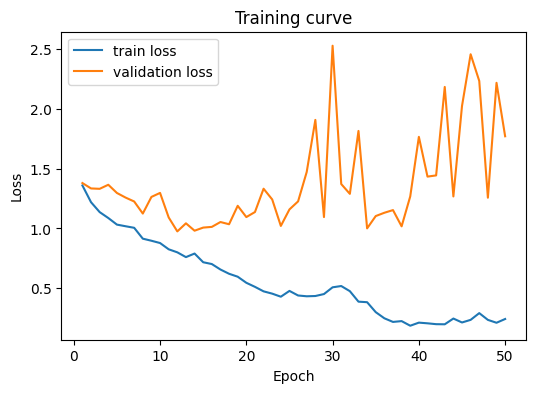

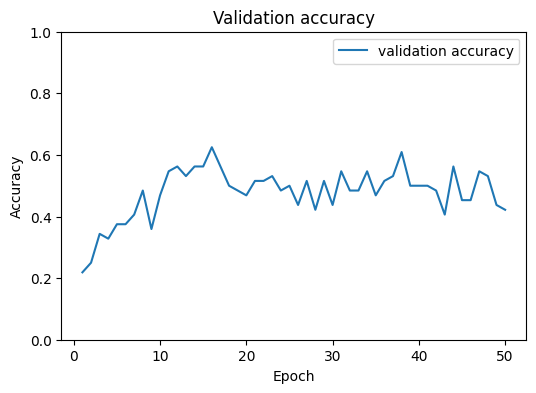

In [6]:
def evaluate(model,loader):
    model.eval(); total=correct=0; loss_sum=0; ys=[]; ps=[]
    with torch.no_grad():
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); logits=model(x); loss=F.cross_entropy(logits,y,weight=class_weights); pred=logits.argmax(1)
            total+=y.numel(); correct+=(pred==y).sum().item(); loss_sum+=loss.item()*y.numel(); ys.append(y.cpu()); ps.append(pred.cpu())
    return {'loss':loss_sum/max(total,1),'accuracy':correct/max(total,1),'y_true':torch.cat(ys).numpy() if ys else np.array([]),'y_pred':torch.cat(ps).numpy() if ps else np.array([])}
def per_class_accuracy(y_true,y_pred):
    return pd.DataFrame([{'damage_class':ID_TO_DAMAGE[i],'n':int((y_true==i).sum()),'accuracy':np.nan if (y_true==i).sum()==0 else float((y_pred[y_true==i]==i).mean())} for i in range(4)])
EPOCHS=50; history=[]
for epoch in range(1,EPOCHS+1):
    model.train(); losses=[]
    for x,y in train_loader:
        x,y=x.to(DEVICE),y.to(DEVICE); loss=F.cross_entropy(model(x),y,weight=class_weights)
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    val=evaluate(model,val_loader); history.append({'epoch':epoch,'train_loss':float(np.mean(losses)),'val_loss':val['loss'],'val_accuracy':val['accuracy']})
    print(f"Epoch {epoch:03d} | train_loss={np.mean(losses):.4f} | val_loss={val['loss']:.4f} | val_acc={val['accuracy']:.3f}")
hist=pd.DataFrame(history); display(hist)
plt.figure(figsize=(6,4)); plt.plot(hist.epoch,hist.train_loss,label='train loss'); plt.plot(hist.epoch,hist.val_loss,label='validation loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Training curve'); plt.show()
plt.figure(figsize=(6,4)); plt.plot(hist.epoch,hist.val_accuracy,label='validation accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.ylim(0,1); plt.legend(); plt.title('Validation accuracy'); plt.show()

#Required Task 10
##Visual Risk Scorecard for Property Underwriting
Your task is to build a Visual Risk Scorecard for Property Underwriting using the `xbd_teaching_subset` dataset and the damage-classification model developed in MLM9.

**Objective:** Move beyond simple classification accuracy and convert model predictions into a business-oriented risk score and underwriting or claims action.

###Instructions

**Load the Test Data**

•	Use the same processed xBD dataset used in MLM7-MLM9.

•	From `labels.csv`, select only the records where `split == "test"`.

•	Store these records in a new DataFrame, for example `df_test_properties`.

•	Each record should include at least: `post_image, damage_label, and damage_id`.

Example:

`df_test_properties = labels[labels["split"].eq("test")].copy()`


**Load or Train the Damage Classifier**

•	Use the CNN damage classifier from MLM9.

•	You may either load your saved trained model from MLM9, if available, or retrain the MLM9 classifier using the training split.

•	The classifier should output predicted probabilities for the four damage classes: `no-damage, minor-damage, major-damage`, and `destroyed`.

**Generate Predicted Class Probabilities**

•	Iterate through each property image.

•	For each post-disaster image, load the image from post_images/.

•	Run the image through the trained classifier.

•	Convert the model outputs into class probabilities using softmax.

•	Store the probabilities in new columns: `p_no_damage`, `p_minor_damage`, `p_major_damage` and `p_destroyed`.

•	Also store the predicted class label in a new column called `predicted_damage_label`.

**Compute an Expected Damage Score**

•	Create a single numerical damage score for each property using the damage scale below.

•	For each image, compute the expected damage score as the probability-weighted average of the damage classes.

•	Add this value as a new column called `expected_damage_score`. The score should range approximately from 0 to 3.


**Damage scale:**
Damage class	Score

no-damage	-> 0

minor-damage ->	1

major-damage ->	2

destroyed	-> 3

**Expected damage score formula:**

`expected_damage_score = (0 * p_no_damage + 1 * p_minor_damage + 2 * p_major_damage + 3 * p_destroyed)`

**Assign an Underwriting or Claims Action**

•	Use expected_damage_score to assign a recommended business action.

•	Add the recommended action as a new column called `recommended_action`.

**Expected damage score	Recommended action**

< 0.75	`Auto-clear`

0.75 to < 1.75	`Human review`

\>= 1.75	`Urgent inspection / reserve adjustment`

**Evaluate the Risk Scorecard**

•	Compare the model predictions with the ground-truth damage labels.

•	Calculate and report the following: `overall classification accuracy`; `confusion matrix`; `average expected_damage_score` by true `damage_label`; `number of properties assigned to each recommended_action`; `percentage of truly major-damage or destroyed properties` assigned to `Urgent inspection / reserve adjustment`; `percentage of no-damage properties assigned to Auto-clear`.

•	These metrics help evaluate whether the scorecard is useful for business decision-making, not just whether the model is statistically accurate.

**Display Results**

•	Display a sample of `df_test_properties` with the columns listed below.
•	Display a summary table showing `recommended_action`, `number_of_properties`, and `percentage_of_test_set`.


**Sample output columns:**

`post_image, damage_label, predicted_damage_label, p_no_damage, p_minor_damage, p_major_damage, p_destroyed, expected_damage_score, recommended_action`


**Short Written Interpretation**

•	Write a brief interpretation of your results.

•	Address whether the scorecard separates low-risk and high-risk properties reasonably well.

•	Identify which damage classes are most often confused.

•	Discuss whether the action threshold is too conservative or too lenient.

•	Explain whether you would trust this model for full automation, and why or why not.



### Load Test Data

In [14]:
# Select records where split == 'test'
df_test_properties = labels[labels['split'].eq('test')].copy()

# Ensure 'damage_id' is present for consistency with the dataset class
df_test_properties['damage_id'] = df_test_properties['damage_label'].map(DAMAGE_TO_ID)

print(f"Number of test properties: {len(df_test_properties)}")
display(df_test_properties.head())

Number of test properties: 53


,crop_id,tile_id,pre_image,post_image,damage_label,damage_id,bbox_x0,bbox_y0,bbox_x1,bbox_y1,split
2,hurricane-matthew_00000110_0005,hurricane-matthew_00000110,pre_images/hurricane-matthew_00000110_0005_pre...,post_images/hurricane-matthew_00000110_0005_po...,destroyed,3,343,698,382,738,test
5,hurricane-matthew_00000153_0012,hurricane-matthew_00000153,pre_images/hurricane-matthew_00000153_0012_pre...,post_images/hurricane-matthew_00000153_0012_po...,destroyed,3,45,853,71,879,test
11,mexico-earthquake_00000068_0023,mexico-earthquake_00000068,pre_images/mexico-earthquake_00000068_0023_pre...,post_images/mexico-earthquake_00000068_0023_po...,no-damage,0,144,899,216,971,test
22,santa-rosa-wildfire_00000096_0020,santa-rosa-wildfire_00000096,pre_images/santa-rosa-wildfire_00000096_0020_p...,post_images/santa-rosa-wildfire_00000096_0020_...,no-damage,0,280,774,403,897,test
23,hurricane-harvey_00000092_0001,hurricane-harvey_00000092,pre_images/hurricane-harvey_00000092_0001_pre.png,post_images/hurricane-harvey_00000092_0001_pos...,minor-damage,1,251,424,316,489,test


### Prepare for Predictions and Generate Class Probabilities

In [15]:
class TestDamageDataset(Dataset):
    def __init__(self, data_dir, df, image_size=64):
        self.data_dir = Path(data_dir)
        self.df = df.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        return load_image(self.data_dir / r.post_image, self.image_size), int(r.damage_id)


test_ds_for_preds = TestDamageDataset(DATA_DIR, df_test_properties, IMAGE_SIZE)
test_loader_for_preds = DataLoader(test_ds_for_preds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Lists to store results
all_y_true = []
all_y_pred = []
all_probabilities = []

model.eval() # Set model to evaluation mode
with torch.no_grad():
    for x, y_true in test_loader_for_preds:
        x = x.to(DEVICE)
        logits = model(x)
        probabilities = F.softmax(logits, dim=1) # Apply softmax to get probabilities
        predicted_labels = torch.argmax(probabilities, dim=1)

        all_y_true.append(y_true.cpu())
        all_y_pred.append(predicted_labels.cpu())
        all_probabilities.append(probabilities.cpu())

# Concatenate all results
all_y_true = torch.cat(all_y_true).numpy()
all_y_pred = torch.cat(all_y_pred).numpy()
all_probabilities = torch.cat(all_probabilities).numpy()

# Add predicted probabilities and labels to df_test_properties
for i, damage_class in ID_TO_DAMAGE.items():
    df_test_properties[f'p_{damage_class.replace('-', '_')}'] = all_probabilities[:, i]

df_test_properties['predicted_damage_label'] = [ID_TO_DAMAGE[label] for label in all_y_pred]

display(df_test_properties.head())

,crop_id,tile_id,pre_image,post_image,damage_label,damage_id,bbox_x0,bbox_y0,bbox_x1,bbox_y1,split,p_no_damage,p_minor_damage,p_major_damage,p_destroyed,predicted_damage_label
2,hurricane-matthew_00000110_0005,hurricane-matthew_00000110,pre_images/hurricane-matthew_00000110_0005_pre...,post_images/hurricane-matthew_00000110_0005_po...,destroyed,3,343,698,382,738,test,0.247174,0.652524,0.015447,0.084855,minor-damage
5,hurricane-matthew_00000153_0012,hurricane-matthew_00000153,pre_images/hurricane-matthew_00000153_0012_pre...,post_images/hurricane-matthew_00000153_0012_po...,destroyed,3,45,853,71,879,test,0.061984,0.802181,0.030172,0.105663,minor-damage
11,mexico-earthquake_00000068_0023,mexico-earthquake_00000068,pre_images/mexico-earthquake_00000068_0023_pre...,post_images/mexico-earthquake_00000068_0023_po...,no-damage,0,144,899,216,971,test,0.892203,0.013715,0.023572,0.070509,no-damage
22,santa-rosa-wildfire_00000096_0020,santa-rosa-wildfire_00000096,pre_images/santa-rosa-wildfire_00000096_0020_p...,post_images/santa-rosa-wildfire_00000096_0020_...,no-damage,0,280,774,403,897,test,0.108370,0.005633,0.883889,0.002108,major-damage
23,hurricane-harvey_00000092_0001,hurricane-harvey_00000092,pre_images/hurricane-harvey_00000092_0001_pre.png,post_images/hurricane-harvey_00000092_0001_pos...,minor-damage,1,251,424,316,489,test,0.001843,0.022337,0.974706,0.001114,major-damage


### Compute Expected Damage Score

In [16]:
damage_scores_map = {'no-damage': 0, 'minor-damage': 1, 'major-damage': 2, 'destroyed': 3}

def calculate_expected_damage_score(row):
    return (damage_scores_map['no-damage'] * row['p_no_damage'] +
            damage_scores_map['minor-damage'] * row['p_minor_damage'] +
            damage_scores_map['major-damage'] * row['p_major_damage'] +
            damage_scores_map['destroyed'] * row['p_destroyed'])

df_test_properties['expected_damage_score'] = df_test_properties.apply(calculate_expected_damage_score, axis=1)
display(df_test_properties.head())

,crop_id,tile_id,pre_image,post_image,damage_label,damage_id,bbox_x0,bbox_y0,bbox_x1,bbox_y1,split,p_no_damage,p_minor_damage,p_major_damage,p_destroyed,predicted_damage_label,expected_damage_score
2,hurricane-matthew_00000110_0005,hurricane-matthew_00000110,pre_images/hurricane-matthew_00000110_0005_pre...,post_images/hurricane-matthew_00000110_0005_po...,destroyed,3,343,698,382,738,test,0.247174,0.652524,0.015447,0.084855,minor-damage,0.937984
5,hurricane-matthew_00000153_0012,hurricane-matthew_00000153,pre_images/hurricane-matthew_00000153_0012_pre...,post_images/hurricane-matthew_00000153_0012_po...,destroyed,3,45,853,71,879,test,0.061984,0.802181,0.030172,0.105663,minor-damage,1.179513
11,mexico-earthquake_00000068_0023,mexico-earthquake_00000068,pre_images/mexico-earthquake_00000068_0023_pre...,post_images/mexico-earthquake_00000068_0023_po...,no-damage,0,144,899,216,971,test,0.892203,0.013715,0.023572,0.070509,no-damage,0.272387
22,santa-rosa-wildfire_00000096_0020,santa-rosa-wildfire_00000096,pre_images/santa-rosa-wildfire_00000096_0020_p...,post_images/santa-rosa-wildfire_00000096_0020_...,no-damage,0,280,774,403,897,test,0.108370,0.005633,0.883889,0.002108,major-damage,1.779736
23,hurricane-harvey_00000092_0001,hurricane-harvey_00000092,pre_images/hurricane-harvey_00000092_0001_pre.png,post_images/hurricane-harvey_00000092_0001_pos...,minor-damage,1,251,424,316,489,test,0.001843,0.022337,0.974706,0.001114,major-damage,1.975091


### Assign Underwriting or Claims Action

In [17]:
def assign_recommended_action(score):
    if score < 0.75:
        return 'Auto-clear'
    elif 0.75 <= score < 1.75:
        return 'Human review'
    else:
        return 'Urgent inspection / reserve adjustment'

df_test_properties['recommended_action'] = df_test_properties['expected_damage_score'].apply(assign_recommended_action)
display(df_test_properties.head())

,crop_id,tile_id,pre_image,post_image,damage_label,damage_id,bbox_x0,bbox_y0,bbox_x1,bbox_y1,split,p_no_damage,p_minor_damage,p_major_damage,p_destroyed,predicted_damage_label,expected_damage_score,recommended_action
2,hurricane-matthew_00000110_0005,hurricane-matthew_00000110,pre_images/hurricane-matthew_00000110_0005_pre...,post_images/hurricane-matthew_00000110_0005_po...,destroyed,3,343,698,382,738,test,0.247174,0.652524,0.015447,0.084855,minor-damage,0.937984,Human review
5,hurricane-matthew_00000153_0012,hurricane-matthew_00000153,pre_images/hurricane-matthew_00000153_0012_pre...,post_images/hurricane-matthew_00000153_0012_po...,destroyed,3,45,853,71,879,test,0.061984,0.802181,0.030172,0.105663,minor-damage,1.179513,Human review
11,mexico-earthquake_00000068_0023,mexico-earthquake_00000068,pre_images/mexico-earthquake_00000068_0023_pre...,post_images/mexico-earthquake_00000068_0023_po...,no-damage,0,144,899,216,971,test,0.892203,0.013715,0.023572,0.070509,no-damage,0.272387,Auto-clear
22,santa-rosa-wildfire_00000096_0020,santa-rosa-wildfire_00000096,pre_images/santa-rosa-wildfire_00000096_0020_p...,post_images/santa-rosa-wildfire_00000096_0020_...,no-damage,0,280,774,403,897,test,0.108370,0.005633,0.883889,0.002108,major-damage,1.779736,Urgent inspection / reserve adjustment
23,hurricane-harvey_00000092_0001,hurricane-harvey_00000092,pre_images/hurricane-harvey_00000092_0001_pre.png,post_images/hurricane-harvey_00000092_0001_pos...,minor-damage,1,251,424,316,489,test,0.001843,0.022337,0.974706,0.001114,major-damage,1.975091,Urgent inspection / reserve adjustment


### Evaluate the Risk Scorecard

Overall Classification Accuracy: 0.4717


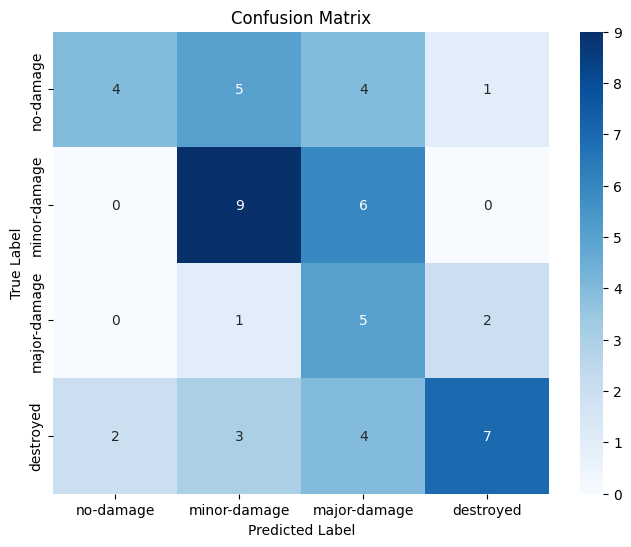

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Overall Classification Accuracy
overall_accuracy = (all_y_pred == all_y_true).mean()
print(f"Overall Classification Accuracy: {overall_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[ID_TO_DAMAGE[i] for i in range(4)],
            yticklabels=[ID_TO_DAMAGE[i] for i in range(4)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
# Average expected_damage_score by true damage_label
avg_expected_score_by_true_label = df_test_properties.groupby('damage_label')['expected_damage_score'].mean().reset_index()
avg_expected_score_by_true_label = avg_expected_score_by_true_label.sort_values(by='expected_damage_score')
print("\nAverage Expected Damage Score by True Damage Label:")
display(avg_expected_score_by_true_label)

# Number of properties assigned to each recommended_action
action_counts = df_test_properties['recommended_action'].value_counts().reset_index()
action_counts.columns = ['recommended_action', 'number_of_properties']
action_counts['percentage_of_test_set'] = (action_counts['number_of_properties'] / len(df_test_properties)) * 100
print("\nProperties per Recommended Action:")
display(action_counts)

# Percentage of truly major-damage or destroyed properties assigned to Urgent inspection / reserve adjustment
high_risk_true = df_test_properties[df_test_properties['damage_label'].isin(['major-damage', 'destroyed'])]
high_risk_action = high_risk_true[high_risk_true['recommended_action'] == 'Urgent inspection / reserve adjustment']
percentage_high_risk_action = (len(high_risk_action) / len(high_risk_true)) * 100 if len(high_risk_true) > 0 else 0
print(f"\nPercentage of truly major-damage or destroyed properties assigned to 'Urgent inspection / reserve adjustment': {percentage_high_risk_action:.2f}%")

# Percentage of no-damage properties assigned to Auto-clear
no_damage_true = df_test_properties[df_test_properties['damage_label'] == 'no-damage']
no_damage_autoclear = no_damage_true[no_damage_true['recommended_action'] == 'Auto-clear']
percentage_no_damage_autoclear = (len(no_damage_autoclear) / len(no_damage_true)) * 100 if len(no_damage_true) > 0 else 0
print(f"Percentage of no-damage properties assigned to 'Auto-clear': {percentage_no_damage_autoclear:.2f}%")


Average Expected Damage Score by True Damage Label:


,damage_label,expected_damage_score
3,no-damage,1.250163
2,minor-damage,1.421226
0,destroyed,1.821963
1,major-damage,2.012338



Properties per Recommended Action:


,recommended_action,number_of_properties,percentage_of_test_set
0,Urgent inspection / reserve adjustment,26,49.056604
1,Human review,21,39.622642
2,Auto-clear,6,11.320755



Percentage of truly major-damage or destroyed properties assigned to 'Urgent inspection / reserve adjustment': 70.83%
Percentage of no-damage properties assigned to 'Auto-clear': 28.57%


### Display Results

In [21]:
display_columns = [
    'post_image', 'damage_label', 'predicted_damage_label',
    'p_no_damage', 'p_minor_damage', 'p_major_damage', 'p_destroyed',
    'expected_damage_score', 'recommended_action'
]

print("\nSample of df_test_properties with scorecard results:")
display(df_test_properties[display_columns].head(10))

print("\nSummary table of recommended_action:")
display(action_counts)


Sample of df_test_properties with scorecard results:


,post_image,damage_label,predicted_damage_label,p_no_damage,p_minor_damage,p_major_damage,p_destroyed,expected_damage_score,recommended_action
2,post_images/hurricane-matthew_00000110_0005_po...,destroyed,minor-damage,0.247174,0.652524,0.015447,0.084855,0.937984,Human review
5,post_images/hurricane-matthew_00000153_0012_po...,destroyed,minor-damage,0.061984,0.802181,0.030172,0.105663,1.179513,Human review
11,post_images/mexico-earthquake_00000068_0023_po...,no-damage,no-damage,0.892203,0.013715,0.023572,0.070509,0.272387,Auto-clear
22,post_images/santa-rosa-wildfire_00000096_0020_...,no-damage,major-damage,0.108370,0.005633,0.883889,0.002108,1.779736,Urgent inspection / reserve adjustment
23,post_images/hurricane-harvey_00000092_0001_pos...,minor-damage,major-damage,0.001843,0.022337,0.974706,0.001114,1.975091,Urgent inspection / reserve adjustment
31,post_images/hurricane-florence_00000453_0005_p...,major-damage,major-damage,0.002799,0.008948,0.987126,0.001128,1.986582,Urgent inspection / reserve adjustment
72,post_images/santa-rosa-wildfire_00000007_0016_...,destroyed,destroyed,0.000166,0.000031,0.000031,0.999772,2.999409,Urgent inspection / reserve adjustment
99,post_images/santa-rosa-wildfire_00000237_0001_...,destroyed,destroyed,0.004978,0.000369,0.000846,0.993806,2.983480,Urgent inspection / reserve adjustment
100,post_images/hurricane-matthew_00000305_0016_po...,minor-damage,minor-damage,0.008937,0.889289,0.076573,0.025201,1.118038,Human review
103,post_images/socal-fire_00000862_0023_post.png,destroyed,destroyed,0.041780,0.192054,0.332781,0.433386,2.157772,Urgent inspection / reserve adjustment



Summary table of recommended_action:


,recommended_action,number_of_properties,percentage_of_test_set
0,Urgent inspection / reserve adjustment,26,49.056604
1,Human review,21,39.622642
2,Auto-clear,6,11.320755


### Short Written Interpretation

- Overall accuracy: 47.17%
- Avg expected score by true class: no-damage 1.25 → minor 1.42 → destroyed 1.82 → major 2.01
- % of major/destroyed sent to Urgent inspection: 70.83%
- % of no-damage sent to Auto-clear: 28.57% (only 2 out of 7)
- Action split: Urgent 49% · Human review 40% · Auto-clear 11%
- Confusion pattern (from sample rows): the model often confuses destroyed → minor-damage and no-damage → major-damage


**Interpretation**

The scorecard does an okay job at separating high-risk from low-risk properties, but only partially. The average expected damage score goes up as the true damage gets worse (no-damage 1.25, minor 1.42, destroyed 1.82, major 2.01), so there is a clear trend in the right direction. However, the gap between no-damage (1.25) and minor-damage (1.42) is very small, which means the model struggles to tell apart properties that are fine from those with light damage. Also, the destroyed class ends up with a lower average score than major-damage, which is the opposite of what we would expect.
The classes that get confused the most are destroyed vs minor-damage (the model often predicts minor-damage when the building is actually destroyed) and no-damage vs major-damage (some untouched properties get predicted as major-damage with high confidence). The overall accuracy is only 47%, which confirms that the model is not reliable at the class level.
Looking at the action thresholds, the rule seems too aggressive on the high end and too lenient on the low end. About 49% of all test properties get flagged for urgent inspection, which is a lot, and only 11% are auto-cleared. On the safety side, the scorecard catches 70.83% of truly major or destroyed properties as urgent, which is decent but still leaves almost 30% of severe cases not flagged. On the auto-clear side, only 28.57% of truly no-damage properties get auto-cleared, so the model is over-cautious here, which means more manual work for the team. The thresholds could be tuned, but with this accuracy the bigger problem is the model itself, not the cut-offs.
I would not trust this model for full automation. The accuracy is below 50%, severe damage cases are sometimes labelled as minor, and undamaged properties can be flagged as major-damage. For an underwriting or claims context this is risky, since either the company pays out wrongly or it ignores real damage. The current scorecard is useful as a triage tool to help humans prioritise their workload, but every decision (specially Auto-clear and Urgent inspection) should still be reviewed by a person before any money or resources are committed.